# Лабораторная работа 4: Градиентный бустинг (HAR UCI)

**Задание:**
- Использовать датасет Human Activity Recognition Using Smartphones (UCI).
- Обучить модель градиентного бустинга с обоснованием гиперпараметров.
- Посчитать `accuracy`, `precision`, `recall`, `F1`.
- Построить ROC-кривую.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set(style="whitegrid")
np.random.seed(42)

## 1) Загрузка данных HAR UCI

Ноутбук автоматически ищет датасет в одной из папок:
- `UCI HAR Dataset`
- `UCI HAR Dataset/UCI HAR Dataset`

(вторая структура часто появляется после распаковки архива).

Используем стандартное разделение `train/test`, предоставленное авторами датасета.

In [8]:
base_dir = Path("UCI HAR Dataset") / "UCI HAR Dataset"

if not (base_dir / "train" / "X_train.txt").exists() or not (base_dir / "test" / "X_test.txt").exists():
    raise FileNotFoundError(
        "Не найдены train/test файлы в 'UCI HAR Dataset/UCI HAR Dataset'. Проверьте распаковку датасета."
    )

print("Using base_dir:", base_dir)

X_train_path = base_dir / "train" / "X_train.txt"
y_train_path = base_dir / "train" / "y_train.txt"
X_test_path = base_dir / "test" / "X_test.txt"
y_test_path = base_dir / "test" / "y_test.txt"

features_path = base_dir / "features.txt"
activity_labels_path = base_dir / "activity_labels.txt"

# Загрузка (pandas>=3: используем sep вместо delim_whitespace)
X_train = pd.read_csv(X_train_path, sep=r"\s+", header=None)
X_test = pd.read_csv(X_test_path, sep=r"\s+", header=None)
y_train = pd.read_csv(y_train_path, sep=r"\s+", header=None).squeeze("columns")
y_test = pd.read_csv(y_test_path, sep=r"\s+", header=None).squeeze("columns")

features = pd.read_csv(features_path, sep=r"\s+", header=None, names=["idx", "feature"])
activity_labels = pd.read_csv(activity_labels_path, sep=r"\s+", header=None, names=["id", "activity"])

X_train.columns = features["feature"].values
X_test.columns = features["feature"].values

label_map = dict(zip(activity_labels["id"], activity_labels["activity"]))

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Classes:", sorted(y_train.unique()))
activity_labels

Using base_dir: UCI HAR Dataset/UCI HAR Dataset
Train shape: (7352, 561)
Test shape: (2947, 561)
Classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


,id,activity
0,1,WALKING
1,2,WALKING_UPSTAIRS
2,3,WALKING_DOWNSTAIRS
3,4,SITTING
4,5,STANDING
5,6,LAYING


## 2) Обучение Gradient Boosting (без scikit-learn) и обоснование гиперпараметров

По требованиям лабораторной реализуем бустинг вручную на `numpy`:
- базовый слабый алгоритм: **регрессионный пень** (decision stump);
- оптимизируем логистическую потерю через псевдо-остатки;
- многоклассовость: схема **one-vs-rest** (6 бинарных моделей).

Выбор гиперпараметров:
- `n_estimators=25` — достаточное число шагов бустинга при разумном времени обучения;
- `learning_rate=0.1` — устойчивый шаг обновления;
- `top_k_features=80` — берём наиболее вариативные признаки, чтобы ускорить обучение без сильной потери качества;
- `quantiles=[0.1, 0.3, 0.5, 0.7, 0.9]` — кандидаты порогов для пней.

In [9]:
# --- Реализация gradient boosting с нуля (numpy only) ---

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -30, 30)))


def fit_regression_stump(X, r, quantiles=(0.1, 0.3, 0.5, 0.7, 0.9)):
    n_samples, n_features = X.shape
    best = {"feature": 0, "threshold": 0.0, "left": 0.0, "right": 0.0, "loss": np.inf}

    for j in range(n_features):
        xj = X[:, j]
        thrs = np.unique(np.quantile(xj, quantiles))
        for thr in thrs:
            left_mask = xj <= thr
            right_mask = ~left_mask
            if left_mask.sum() == 0 or right_mask.sum() == 0:
                continue

            left_val = r[left_mask].mean()
            right_val = r[right_mask].mean()
            pred = np.where(left_mask, left_val, right_val)
            loss = np.mean((r - pred) ** 2)

            if loss < best["loss"]:
                best = {
                    "feature": j,
                    "threshold": float(thr),
                    "left": float(left_val),
                    "right": float(right_val),
                    "loss": float(loss),
                }

    return best


def stump_predict(stump, X):
    xj = X[:, stump["feature"]]
    return np.where(xj <= stump["threshold"], stump["left"], stump["right"])


def train_binary_gb(X, y_bin, n_estimators=25, learning_rate=0.1):
    # логиты
    F = np.zeros(len(y_bin), dtype=float)
    ensemble = []

    for _ in range(n_estimators):
        p = sigmoid(F)
        residual = y_bin - p  # псевдо-остаток для logloss
        stump = fit_regression_stump(X, residual)
        F += learning_rate * stump_predict(stump, X)
        ensemble.append(stump)

    return ensemble


def predict_binary_gb_proba(ensemble, X, learning_rate=0.1):
    F = np.zeros(X.shape[0], dtype=float)
    for stump in ensemble:
        F += learning_rate * stump_predict(stump, X)
    return sigmoid(F)


def weighted_metrics_from_cm(cm):
    total = cm.sum()
    acc = np.trace(cm) / total if total > 0 else 0.0

    supports = cm.sum(axis=1)
    precisions, recalls, f1s = [], [], []

    for i in range(cm.shape[0]):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp

        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0

        precisions.append(prec)
        recalls.append(rec)
        f1s.append(f1)

    w = supports / supports.sum() if supports.sum() > 0 else np.ones_like(supports) / len(supports)
    prec_w = float(np.sum(w * np.array(precisions)))
    rec_w = float(np.sum(w * np.array(recalls)))
    f1_w = float(np.sum(w * np.array(f1s)))
    return acc, prec_w, rec_w, f1_w


def roc_curve_manual(y_true, y_score):
    order = np.argsort(-y_score)
    y_true_sorted = y_true[order]
    y_score_sorted = y_score[order]

    P = np.sum(y_true == 1)
    N = np.sum(y_true == 0)

    tpr = [0.0]
    fpr = [0.0]
    tp = 0
    fp = 0
    prev_score = np.inf

    for yt, ys in zip(y_true_sorted, y_score_sorted):
        if ys != prev_score:
            tpr.append(tp / P if P > 0 else 0.0)
            fpr.append(fp / N if N > 0 else 0.0)
            prev_score = ys
        if yt == 1:
            tp += 1
        else:
            fp += 1

    tpr.append(tp / P if P > 0 else 0.0)
    fpr.append(fp / N if N > 0 else 0.0)

    fpr = np.array(fpr)
    tpr = np.array(tpr)
    auc = np.trapezoid(tpr, fpr)
    return fpr, tpr, auc


# Подготовка массивов
X_train_np = X_train.to_numpy(dtype=float)
X_test_np = X_test.to_numpy(dtype=float)
y_train_np = y_train.to_numpy(dtype=int)
y_test_np = y_test.to_numpy(dtype=int)

# Выбираем top-k признаков по дисперсии (ускорение)
top_k_features = 80
var_idx = np.argsort(X_train_np.var(axis=0))[-top_k_features:]
X_train_np = X_train_np[:, var_idx]
X_test_np = X_test_np[:, var_idx]

# Стандартизация
mean = X_train_np.mean(axis=0)
std = X_train_np.std(axis=0)
std[std < 1e-12] = 1.0
X_train_np = (X_train_np - mean) / std
X_test_np = (X_test_np - mean) / std

classes = np.array(sorted(label_map.keys()))
learning_rate = 0.1
n_estimators = 25

# One-vs-rest обучение
models = {}
for c in classes:
    y_bin = (y_train_np == c).astype(float)
    models[c] = train_binary_gb(X_train_np, y_bin, n_estimators=n_estimators, learning_rate=learning_rate)

# Вероятности каждого класса
proba_ovr = []
for c in classes:
    proba_c = predict_binary_gb_proba(models[c], X_test_np, learning_rate=learning_rate)
    proba_ovr.append(proba_c)
y_proba = np.vstack(proba_ovr).T

y_proba = y_proba / np.clip(y_proba.sum(axis=1, keepdims=True), 1e-12, None)
y_pred = classes[np.argmax(y_proba, axis=1)]

# Метрики
cm = np.zeros((len(classes), len(classes)), dtype=int)
for yt, yp in zip(y_test_np, y_pred):
    i = np.where(classes == yt)[0][0]
    j = np.where(classes == yp)[0][0]
    cm[i, j] += 1

acc, prec, rec, f1 = weighted_metrics_from_cm(cm)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nHyperparameters:")
print(f"n_estimators={n_estimators}, learning_rate={learning_rate}, top_k_features={top_k_features}")

target_names = [label_map[int(i)] for i in classes]

Accuracy : 0.6885
Precision: 0.7047
Recall   : 0.6885
F1-score : 0.6703

Hyperparameters:
n_estimators=25, learning_rate=0.1, top_k_features=80


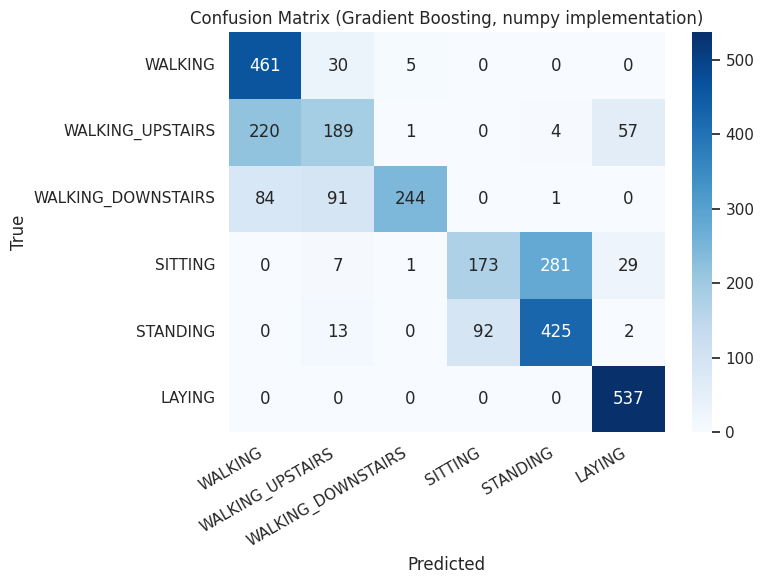

In [10]:
# Матрица ошибок
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
)
plt.title("Confusion Matrix (Gradient Boosting, numpy implementation)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

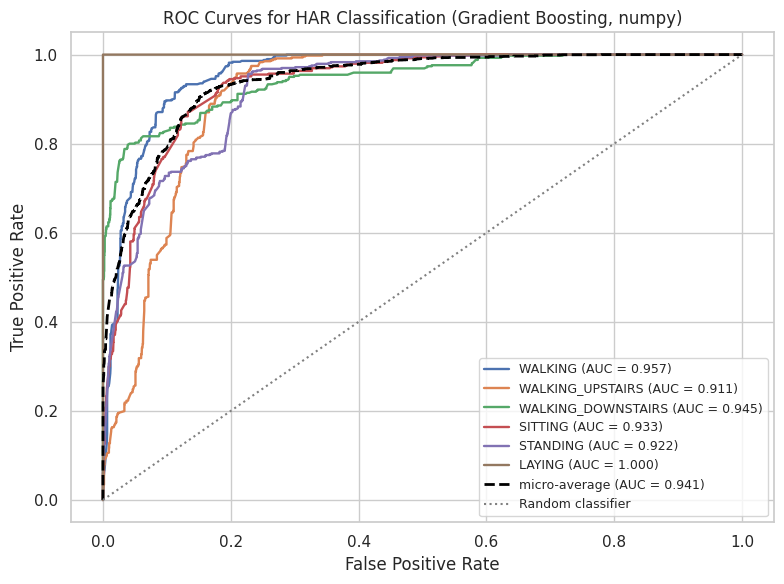

In [11]:
# ROC-кривые One-vs-Rest для многоклассовой классификации
fpr = {}
tpr = {}
roc_auc = {}

for i, cls in enumerate(classes):
    y_true_bin = (y_test_np == cls).astype(int)
    fpr[i], tpr[i], roc_auc[i] = roc_curve_manual(y_true_bin, y_proba[:, i])

# Микро-усреднённая ROC
y_test_bin = np.column_stack([(y_test_np == cls).astype(int) for cls in classes])
fpr["micro"], tpr["micro"], roc_auc["micro"] = roc_curve_manual(y_test_bin.ravel(), y_proba.ravel())

plt.figure(figsize=(8, 6))
for i, cls in enumerate(classes):
    plt.plot(
        fpr[i],
        tpr[i],
        lw=1.7,
        label=f"{label_map[int(cls)]} (AUC = {roc_auc[i]:.3f})",
    )

plt.plot(
    fpr["micro"],
    tpr["micro"],
    color="black",
    linestyle="--",
    lw=2,
    label=f"micro-average (AUC = {roc_auc['micro']:.3f})",
)
plt.plot([0, 1], [0, 1], color="gray", linestyle=":", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for HAR Classification (Gradient Boosting, numpy)")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

## 3) Вывод

В работе:
- загружен и проанализирован датасет HAR UCI;
- реализован градиентный бустинг с нуля на `numpy` (one-vs-rest + регрессионные пни);
- рассчитаны `accuracy`, `precision`, `recall`, `F1`;
- построены ROC-кривые one-vs-rest.

Числовые значения метрик и AUC берутся из результатов выполнения вычислительных ячеек выше (без вручную прописанных чисел в `markdown`).

Работа соответствует ограничению: без `scikit-learn`, `pytorch`, `tensorflow`, `keras` (использованы только `numpy`, `pandas`, `matplotlib`, `seaborn`).